<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 2.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 2.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 1.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>


## تعریف Activation Functions

Activation Functions عملیات ریاضی هستند که روی خروجی هر نورون در شبکه عصبی اعمال می‌شوند. این توابع **غیرخطی** بودن را به مدل اضافه می‌کنند 
تا شبکه بتواند الگوهای پیچیده را یاد بگیرد. بدون تابع فعال‌سازی، شبکه عصبی عمیق صرفاً یک مدل خطی بزرگ خواهد بود.

ویژگی‌های مهم توابع فعال‌سازی:
- معرفی غیرخطی بودن
- کمک به جریان گرادیان در Backpropagation
- جلوگیری یا کاهش مشکلات Vanishing / Exploding Gradient
- تأثیر بر سرعت همگرایی، پایداری آموزش و دقت نهایی

## انواع توابع فعال‌سازی مهم

در این نوت‌بوک توابع زیر را از پایه پیاده‌سازی و مقایسه می‌کنیم:

1. Sigmoid  
2. Tanh  
3. ReLU  
4. Leaky ReLU  
5. ELU (Exponential Linear Unit)  
6. Swish  
7. Softmax (برای نمایش محدود)  
8. Mish (جدیدتر و محبوب)  
9. GELU (بسیار استفاده‌شده در ترانسفورمرها)

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Arial', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
#  کتابخانه‌ها و تنظیمات اولیه

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'   # برای نمایش صحیح فارسی (در صورت نصب فونت)
plt.rcParams['axes.unicode_minus'] = False

x = np.linspace(-2, 2, 400)
# تابع کمکی برای رسم
def plot_activation(x, y, title):
    plt.figure(figsize=(7, 4))
    plt.plot(x, y, label=title)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True)
    plt.legend()
    plt.show()

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Arial', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 1.تابع فعال‌سازی سیگموید (Sigmoid)

**تعریف کوتاه:**  
تابع فعال‌سازی **سیگموید** یک تابع ریاضی است که هر عدد ورودی را به مقداری بین **۰ و ۱** تبدیل می‌کند. به همین دلیل، خروجی آن شبیه «احتمال» تفسیر می‌شود و در بسیاری از شبکه‌های عصبی اولیه استفاده شده است.

فرمول آن:


$$\sigma(x)=\frac{1}{1+e^{-x}}$$
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Arial', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
فرض کنید یک نورون در شبکه عصبی عددی را حساب می‌کند.  
تابع سیگموید مثل یک «فیلتر نرم» عمل می‌کند که نتیجه را فشرده می‌کند تا همیشه بین ۰ و ۱ باشد.  
- اگر ورودی خیلی بزرگ باشد → خروجی نزدیک ۱  
- اگر ورودی خیلی کوچک باشد → خروجی نزدیک ۰  
- اگر ورودی نزدیک صفر باشد → خروجی حدود ۰٫۵  

به این ترتیب، شبکه می‌تواند تصمیم‌های تدریجی بگیرد، نه فقط صفر و یک.

---
**خلاصه یک‌ خطی:**  
تابع سیگموید عدد خروجی نورون را به بازه ۰ تا ۱ می‌برد تا شبکه بتواند یاد بگیرد و تصمیم‌های نرم و قابل آموزش بگیرد.

---

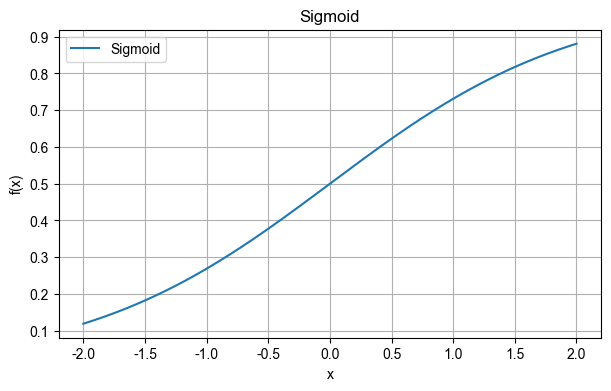

In [32]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

y_sigmoid = sigmoid(x)
plot_activation(x, y_sigmoid, 'Sigmoid')

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 2.تابع فعال‌سازی تانژانت هیپربولیک (tanh)

**تعریف کوتاه:**  
تابع فعال‌سازی **tanh** عدد ورودی را به مقداری بین **۱- و ۱+** تبدیل می‌کند.  
یعنی خروجی می‌تواند منفی یا مثبت باشد و حول صفر متقارن است.

فرمول آن:



$$tanh(x)=\frac{e^x - e^{-x}}{e^x + e^{-x}}$$
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
**توضیح ساده برای دانش‌آموزان:**  
تابع tanh مثل یک «فشرده‌کننده» است که:
- ورودی‌های بزرگ مثبت → نزدیک **۱+**
- ورودی‌های بزرگ منفی → نزدیک **۱-**
- ورودی نزدیک صفر → نزدیک **۰**

به همین دلیل، یادگیری شبکه معمولاً راحت‌تر می‌شود، چون میانگین خروجی‌ها نزدیک صفر است و وزن‌ها بهتر تنظیم می‌شوند.

---

**رفرنس اصلی و کلاسیک:**
  **LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998).**  
  "Gradient-based learning applied to document recognition."  
  Proceedings of the IEEE, 86(11), 2278–2324.  
  (در بخش ۴.۱ به صراحت از tanh به عنوان تابع فعال‌سازی پیشنهادی نام برده شده است)
در این مرجع بیان می‌شود که توابعی مانند **tanh** به دلیل **خروجی متقارن حول صفر** معمولاً برای آموزش شبکه‌های عصبی از سیگموید ساده مناسب‌تر هستند، چون روند یادگیری پایدارتر می‌شود.

---

**خلاصه یک‌خطی:**  
تابع **tanh** خروجی نورون را بین ۱- و ۱+ می‌برد و چون حول صفر متقارن است، یادگیری شبکه عصبی معمولاً بهتر و پایدارتر می‌شود.


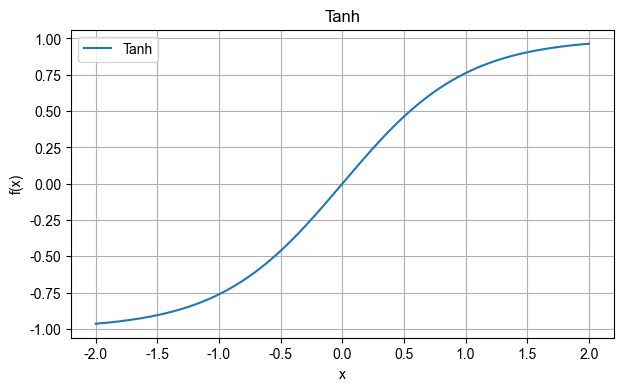

In [33]:
def tanh(x):
    return np.tanh(x)  # یا پیاده‌سازی دستی: (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

y_tanh = tanh(x)
plot_activation(x, y_tanh, 'Tanh')

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>

## 3.تابع فعال‌سازی ReLU (Rectified Linear Unit)

**تعریف کوتاه:**  
تابع فعال‌سازی **ReLU** یک تابع بسیار ساده است که اگر ورودی مثبت باشد همان را برمی‌گرداند، و اگر منفی باشد آن را صفر می‌کند.

فرمول آن:



$$f(x) = \max(0, x)$$
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
یعنی:
-  خروجی برابر خود x اگر $$( x > 0)$$   
-   خروجی برابر 0  اگر$$(x \le 0)$$ 
---

## توضیح ساده

تصور کنید یک نورون داریم که یک عدد تولید می‌کند.  
تابع ReLU مثل یک «کلید یک‌طرفه» عمل می‌کند:

- عددهای مثبت را عبور می‌دهد ✅  
- عددهای منفی را حذف می‌کند (صفر می‌کند) ❌  

به همین دلیل، شبکه فقط روی سیگنال‌های مفید (مثبت) تمرکز می‌کند و محاسبات هم سریع‌تر می‌شود.

---

## اشاره به مقاله اصلی
**رفرنس اصلی و مقاله‌ای که ReLU را معرفی و محبوب کرد:**

**Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012).**  
"ImageNet Classification with Deep Convolutional Neural Networks"  
(معروف به AlexNet)  
Advances in Neural Information Processing Systems 25 (NeurIPS 2012)

در بخش ۳ مقاله، نویسندگان به صراحت نوشتند:  
«We used the rectifier (ReLU) non-linearity f(x) = max(0, x) ... This was key to the success of training deep models quickly.»)

در این مقاله نشان داده شد که استفاده از واحدهای خطی اصلاح‌شده (ReLU) باعث می‌شود آموزش شبکه‌های عمیق سریع‌تر و مؤثرتر انجام شود و مشکل ناپدید شدن گرادیان کمتر شود.

---

## خلاصه یک‌خطی

تابع **ReLU** ورودی‌های منفی را صفر و ورودی‌های مثبت را بدون تغییر عبور می‌دهد؛ همین سادگی باعث شده یکی از مهم‌ترین توابع فعال‌سازی در یادگیری عمیق باشد.


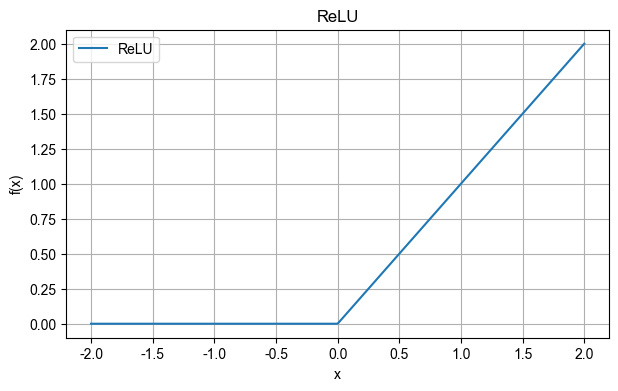

In [34]:
def relu(x):
    return np.maximum(0, x)

y_relu = relu(x)

plot_activation(x, y_relu, 'ReLU')

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 4.تابع فعال‌سازی Leaky ReLU

**تعریف کوتاه:**  
تابع فعال‌سازی **Leaky ReLU** نسخه بهبودیافته‌ی ReLU است.  
در ReLU اگر ورودی منفی باشد، خروجی کاملاً صفر می‌شود.  
اما در Leaky ReLU ورودی‌های منفی به‌طور کامل حذف نمی‌شوند، بلکه با یک ضریب کوچک (مثلاً 0.01) عبور داده می‌شوند.

فرمول آن:



$$f(x) =
\begin{cases}
x & x > 0 \\
\alpha x & x \le 0
\end{cases}
$$
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>

که در آن $$(\alpha)$$ یک عدد کوچک مانند 0.01 است.

---

## توضیح ساده  

فرض کنید نورون یک عدد منفی تولید کند.

- در **ReLU** → این عدد صفر می‌شود (کاملاً خاموش)
- در **Leaky ReLU** → عدد منفی خیلی کوچک عبور می‌کند

یعنی نورون هیچ‌وقت کاملاً خاموش نمی‌شود.  
به این مشکل در ReLU می‌گویند **"نورون مرده" (Dying ReLU)**.

Leaky ReLU کمک می‌کند یادگیری بهتر ادامه پیدا کند، حتی اگر ورودی‌ها منفی باشند.

---

## اشاره به مقاله اصلی

ایده استفاده در مقاله:
**Maas, A. L., Hannun, A. Y., & Ng, A. Y. (2013).**  
"Rectifier Nonlinearities Improve Neural Network Acoustic Models"  
International Conference on Machine Learning (ICML) Workshop on Deep Learning for Audio, Speech and Language Processing.

در این مقاله نویسندگان نوشتند:  
«We introduce a new rectifier nonlinearity called Leaky ReLU, defined as f(x) = max(αx, x) where α is a small constant (e.g., 0.01). This allows a small, non-zero gradient when the unit is not active.»

در این کار نشان داده شد که استفاده از نسخه‌های اصلاح‌شده‌ی ReLU (از جمله Leaky ReLU) می‌تواند عملکرد شبکه‌های عصبی را بهبود دهد و مشکل نورون‌های غیرفعال را کاهش دهد.

---

## خلاصه یک‌خطی  

تابع **Leaky ReLU** مثل ReLU است، اما اجازه می‌دهد مقدارهای منفی کمی عبور کنند تا نورون‌ها خاموش نشوند و یادگیری بهتر انجام شود.

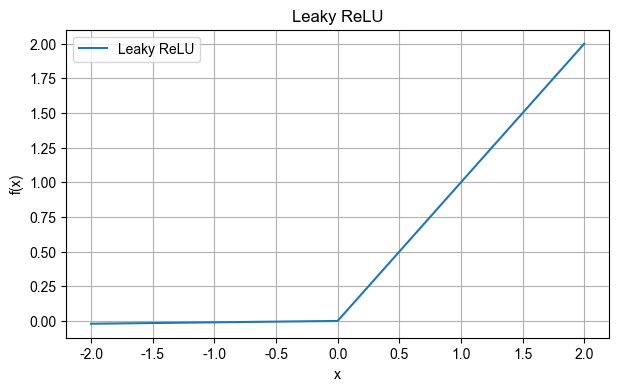

In [35]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

y_leaky = leaky_relu(x)
plot_activation(x, y_leaky, 'Leaky ReLU')

یه تعریف مختصر از Activation function ELU
میخوام فارسی باشه و از مقاله اصلی گرفته شده باشه و به اون رفرنس بده سعی کن روان توضیح بدی برای آموزش به دانشآموزان میخوام
خروجیت markdown باشد

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 5.تابع فعال‌سازی ELU (Exponential Linear Unit)

**تعریف کوتاه:**  
تابع فعال‌سازی **ELU** شبیه ReLU عمل می‌کند، با این تفاوت که برای ورودی‌های منفی مقدار را صفر نمی‌کند، بلکه به‌صورت نمایی به سمت یک مقدار منفی محدود نزدیک می‌شود.

فرمول آن:



$$
f(x)=
\begin{cases}
x & x>0 \\
\alpha (e^x-1) & x \le 0
\end{cases}
$$
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
که در آن $$( \alpha )$$ یک عدد ثابت (معمولاً 1) است.

---

## توضیح ساده 

تابع ELU این‌طور رفتار می‌کند:

- عددهای مثبت → بدون تغییر عبور می‌کنند  
- عددهای منفی → به‌جای صفر شدن، به آرامی به یک مقدار منفی کوچک نزدیک می‌شوند  

این کار دو مزیت دارد:
1. نورون‌ها کاملاً خاموش نمی‌شوند  
2. میانگین خروجی‌ها به صفر نزدیک‌تر می‌شود و یادگیری پایدارتر می‌شود  

می‌توان گفت ELU ترکیبی از مزیت‌های **ReLU** و توابع نرم‌تر مثل tanh است.

---

## اشاره به مقاله اصلی

**Clevert, D.-A., Unterthiner, T., & Hochreiter, S. (2015).**  
"Fast and Accurate Deep Network Learning by Exponential Linear Units (ELUs)"  
International Conference on Learning Representations (ICLR 2016).  
arXiv:1511.07289

در چکیده مقاله آمده:  
«We introduce the exponential linear unit (ELU) which speeds up learning in deep neural networks and leads to higher classification accuracies.»

در این مقاله نشان داده شد که ELU می‌تواند سرعت یادگیری شبکه‌های عمیق را افزایش دهد و دقت مدل را بهبود دهد، به‌خصوص به دلیل اینکه خروجی‌های منفی کنترل‌شده تولید می‌کند و مشکل کند شدن یادگیری را کاهش می‌دهد.

---

## خلاصه یک‌خطی

تابع **ELU** مثل ReLU برای ورودی‌های مثبت عمل می‌کند، اما برای ورودی‌های منفی مقدار نرم و منفی تولید می‌کند تا یادگیری شبکه سریع‌تر و پایدارتر شود.

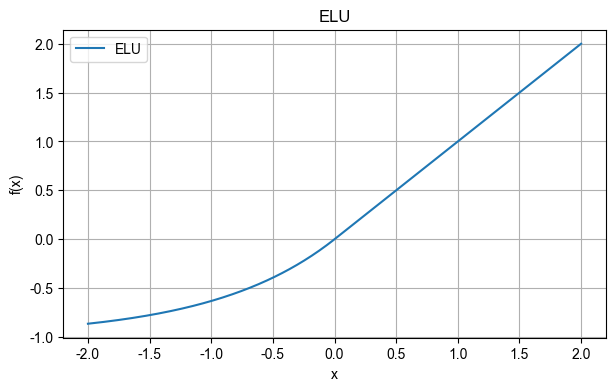

In [36]:
def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

y_elu = elu(x)
plot_activation(x, y_elu, 'ELU')

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 6.تابع فعال‌سازی Swish

**تعریف کوتاه:**  
تابع فعال‌سازی **Swish** یک تابع نرم و پیوسته است که از ضرب ورودی در سیگموید همان ورودی به‌دست می‌آید.

فرمول آن:




$$f(x) = x \cdot \sigma(x) = x \cdot \frac{1}{1+e^{-x}}
$$

گاهی به صورت کلی‌تر نوشته می‌شود:

$$f(x) = x \cdot \sigma(\beta x)
$$
که در آن $$( \beta )$$ می‌تواند یک عدد ثابت یا قابل‌آموزش باشد.
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
---

## توضیح ساده  

Swish مثل این است که:

1. اول با تابع سیگموید بررسی کنیم «چقدر باید ورودی را عبور دهیم».
2. بعد همان مقدار را در خود ورودی ضرب کنیم.

نتیجه چه می‌شود؟

- ورودی‌های بزرگ مثبت → تقریباً کامل عبور می‌کنند  
- ورودی‌های نزدیک صفر → کمی تضعیف می‌شوند  
- ورودی‌های منفی → کاملاً حذف نمی‌شوند (برخلاف ReLU)، بلکه به شکل نرم عبور می‌کنند  

این رفتار نرم باعث می‌شود یادگیری شبکه روان‌تر و در بعضی موارد دقیق‌تر شود.

---

## اشاره به مقاله اصلی

**Ramachandran, P., Zoph, B., & Le, Q. V. (2017).**  
"Searching for Activation Functions"  
arXiv:1710.05941v2  
(منتشر شده توسط تیم Google Brain)

در چکیده مقاله آمده:  
«We propose a new activation function, Swish, defined as f(x) = x · σ(βx). Swish tends to perform better than ReLU on deep models across a number of challenging datasets.»


## خلاصه یک‌خطی  

تابع **Swish** ورودی را در سیگموید خودش ضرب می‌کند؛ نرم است، مقدارهای منفی را کاملاً حذف نمی‌کند و در بسیاری از شبکه‌های عمیق عملکرد خوبی نشان داده است.


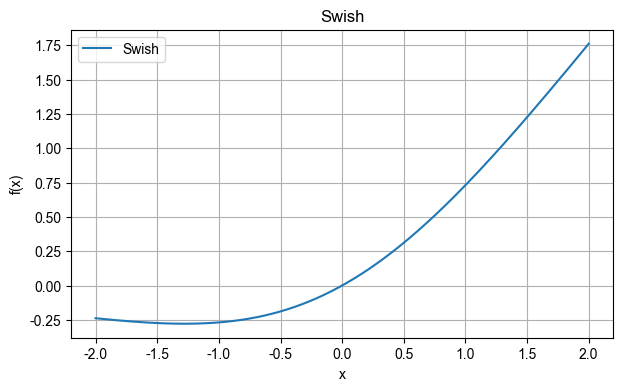

In [53]:
def swish(x, beta=1.0):
    return x * (1 / (1 + np.exp(-beta * x)))

y_swish = swish(x, beta=1.0)
plot_activation(x, y_swish, 'Swish')

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>

## 7.تابع فعال‌سازی Mish

**تعریف کوتاه:**  
تابع فعال‌سازی **Mish** یک تابع نرم و پیوسته است که از ضرب ورودی در تانژانت هیپربولیکِ تابع Softplus ساخته می‌شود.

فرمول آن:




$$
f(x)=x \cdot \tanh(\ln(1+e^x))$$

که در آن:
$$
Softplus(x)=\ln(1+e^x)
$$
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>

---

## توضیح ساده 

تابع Mish این‌طور رفتار می‌کند:

- عددهای مثبت → تقریباً بدون تغییر عبور می‌کنند  
- عددهای منفی → کاملاً حذف نمی‌شوند و مقدار کمی عبور می‌کنند  
- تغییرات خروجی کاملاً نرم است (هیچ شکستگی تند ندارد)

می‌توان گفت Mish شبیه ReLU است، اما نرم‌تر و هوشمندانه‌تر عمل می‌کند و گاهی باعث می‌شود شبکه بهتر یاد بگیرد.

---

## اشاره به مقاله اصلی

**Misra, D. (2019).**  
"Mish: A Self Regularized Non-Monotonic Activation Function"  
arXiv:1908.08681  
(نسخه به‌روزرسانی‌شده در سال‌های بعد هم منتشر شد)

در چکیده مقاله آمده:  
«We propose Mish, a novel self-regularized non-monotonic activation function ... which outperforms ReLU, Swish, and other state-of-the-art activations on various tasks.»

در این مقاله نشان داده شد که Mish به دلیل **نرم بودن، پیوستگی مشتق، و اجازه عبور کنترل‌شده مقادیر منفی** می‌تواند در بسیاری از شبکه‌های عمیق عملکرد خوبی ایجاد کند و در بعضی مدل‌ها دقت بالاتری نسبت به ReLU به دست آمده است.

---

## خلاصه یک‌خطی 

تابع **Mish** یک تابع نرم است که مقدارهای مثبت را عبور می‌دهد و مقدارهای منفی را به‌صورت ملایم حفظ می‌کند، و همین باعث می‌شود یادگیری شبکه در بعضی مسائل بهتر شود.

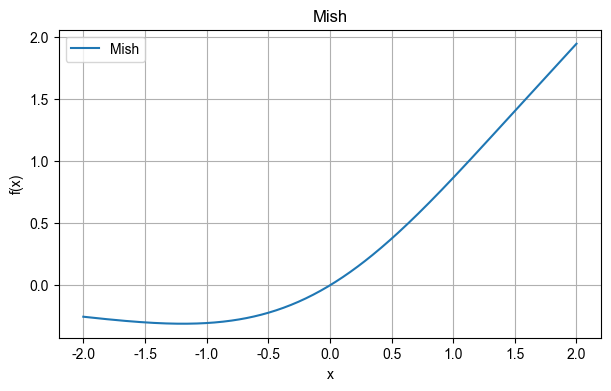

In [38]:
def mish(x):
    return x * np.tanh(np.log(1 + np.exp(x)))

y_mish = mish(x)
plot_activation(x, y_mish, 'Mish')

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 8.تابع فعال‌سازی GELU (Gaussian Error Linear Unit)

**تعریف کوتاه:**  
تابع فعال‌سازی **GELU** ورودی را بر اساس یک توزیع نرمال (گاوسی) به‌صورت نرم وزن‌دهی می‌کند.  
برخلاف ReLU که ناگهانی صفر می‌کند، GELU به شکل احتمالی تصمیم می‌گیرد چه مقدار از ورودی عبور کند.

فرمول اصلی آن:





$$f(x)= x \cdot \Phi(x)$$


که در آن $$( \Phi(x) )$$ تابع توزیع تجمعی نرمال استاندارد (Gaussian CDF) است.

تقریب رایج محاسباتی:


$$f(x) \approx 0.5x \left(1+\tanh\left(\sqrt{\frac{2}{\pi}}(x+0.044715x^3)\right)\right)
$$
<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
---

## توضیح ساده برای دانش‌آموزان

تصور کنید هر نورون قبل از عبور دادن یک عدد، یک «احتمال هوشمند» حساب می‌کند.

- اگر عدد خیلی بزرگ مثبت باشد → تقریباً کامل عبور می‌کند  
- اگر خیلی منفی باشد → تقریباً حذف می‌شود  
- اگر نزدیک صفر باشد → بخشی از آن عبور می‌کند  

یعنی به‌جای یک تصمیم ناگهانی (مثل ReLU)، GELU یک تصمیم نرم و تدریجی می‌گیرد.

---

## اشاره به مقاله اصلی

**Hendrycks, D., & Gimpel, K. (2016).**  
"Gaussian Error Linear Units (GELUs)"  
arXiv:1606.08415  
(بعداً در بسیاری از کارهای Transformer به کار گرفته شد)

در چکیده مقاله آمده:  
«We propose the Gaussian Error Linear Unit (GELU), ... which consistently outperforms the ReLU and ELU across a variety of tasks.»

در این مقاله نشان داده شد که GELU در بسیاری از شبکه‌های عمیق (به‌ویژه مدل‌های پردازش زبان طبیعی) عملکرد بسیار خوبی دارد. بعدها این تابع در مدل‌های بزرگی مانند Transformer و BERT نیز استفاده شد.

---

## خلاصه یک‌خطی برای تدریس

تابع **GELU** به‌صورت نرم و احتمالی تصمیم می‌گیرد چه مقدار از ورودی عبور کند، و همین رفتار تدریجی باعث عملکرد قوی آن در شبکه‌های عمیق مدرن شده است.

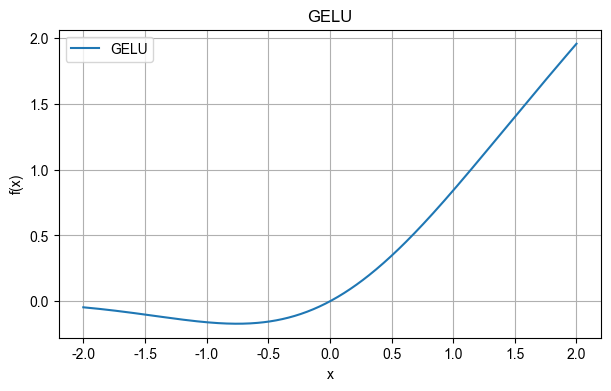

In [39]:
def gelu(x):
    return x * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

y_gelu = gelu(x)
plot_activation(x, y_gelu, 'GELU')

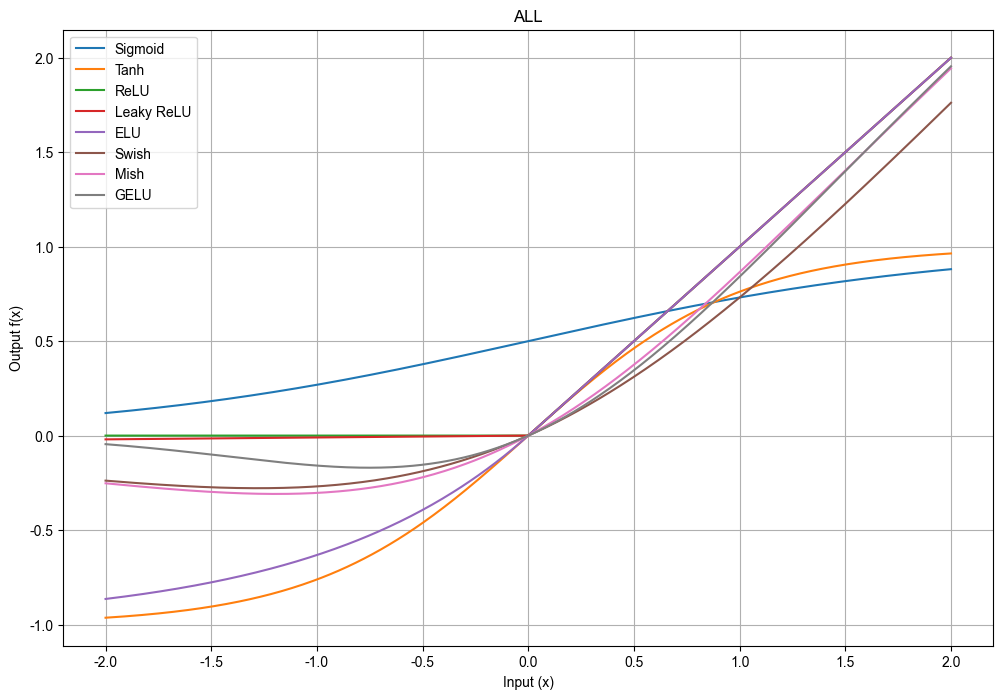

In [45]:
# سلول مقایسه نهایی
plt.figure(figsize=(12,8))

plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_leaky, label='Leaky ReLU')
plt.plot(x, y_elu, label='ELU')
plt.plot(x, y_swish, label='Swish')
plt.plot(x, y_mish, label='Mish')
plt.plot(x, y_gelu, label='GELU')

plt.title('ALL')
plt.xlabel('Input (x)')
plt.ylabel('Output f(x)')
plt.grid(True)
plt.legend(loc='best')
plt.show()


In [ ]:
def parabolic_cone(x):
    return x * (2 - x)
y = parabolic_cone(x)


def Cone(x):
    return 1 - np.abs(x - 1)
y = Cone(x)

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>

## متریک‌های مهم برای مقایسه توابع فعال‌سازی (بر اساس مقالات معتبر ۲۰۲۴-۲۰۲۵)
1. محدوده خروجی (Output Range): محدود یا نامحدود بودن → مناسب برای احتمال یا رگرسیون
2. مونوتونیک بودن: صعودی بودن یا نبودن → پایداری گرادیان
3. نرمی (Smoothness): مشتق‌پذیری پیوسته → بهینه‌سازی بهتر
4. جریان گرادیان: جلوگیری از Vanishing/Exploding
5. سرعت همگرایی: تعداد epochهای کمتر برای رسیدن به دقت خوب
6. دقت نهایی (Accuracy): در وظایف مختلف (تصویر، متن و ...)
7. زمان محاسباتی: تعداد عملیات (ReLU خیلی سریع)
8. پایداری آموزش: مقاومت در برابر نویز و initialization بد
9. مقیاس‌پذیری: عملکرد در شبکه‌های خیلی عمیق (>۱۰۰ لایه)

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
---


یک مثال ساده برای آموزش شبکه عصبی چندلایه (MLP) روی داده ساختگی، هدف اصلی مقایسه عملکرد توابع فعال‌سازی مختلف است.

## 🔹 شرح کوتاه

داده‌های ساختگی ایجاد میشوند : ۵۰۰ نمونه با ۱۰ ویژگی هرکدام.

برچسب‌ها دودویی انتخاب میشود: ۰ یا ۱، بر اساس مجموع ویژگی‌ها.

یک شبکه عصبی کوچک با یک لایه مخفی و یک نورون خروجی ساخته میشود.

شبکه با توابع فعال‌سازی مختلف (Sigmoid, ReLU, Tanh, Swish و …) آموزش داده می‌شود.

روند کاهش Loss در طول آموزش رسم می‌شود تا ببینیم کدام تابع سریع‌تر و بهتر یاد می‌گیرد.

---

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 1️⃣ ایجاد داده‌ها
``` python
X = np.random.randn(500, 10)
y = (np.sum(X, axis=1) > 0).astype(int)
```

X = داده‌ها (۵۰۰ نمونه، هر نمونه ۱۰ ویژگی)

y = برچسب ۰ یا ۱

قانون ساده: اگر مجموع ویژگی‌ها مثبت باشد، برچسب ۱؛ در غیر این صورت ۰

In [47]:
np.random.seed(42)

# داده ساختگی ساده (دودویی)
X = np.random.randn(500, 10)
y = (np.sum(X, axis=1) > 0).astype(int)  # برچسب ساده


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 2️⃣ تعریف ساختار شبکه و پارامترها

- ۱۰ ورودی → لایه مخفی ۳۲ نورون → خروجی ۱ نورون

- یادگیری با نرخ 0.01 و ۱۰۰۰ بار مرور داده‌ها (epoch)

In [48]:
# پارامترها
input_size = 10
hidden_size = 32
output_size = 1
learning_rate = 0.01
epochs = 1000

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 3️⃣ تابع آموزش شبکه
```python
def train_with_activation(activation_func, name):
    ...
```
این تابع مراحل زیر را انجام می‌دهد:

### الف) مقداردهی اولیه وزن‌ها و بایاس‌ها

- وزن‌ها کوچک تصادفی هستند

- بایاس‌ها صفر هستند

### ب) حلقه آموزش (forward + backward)

####  Forward Pass:
``` python 
z1 = X @ W1 + b1
a1 = activation_func(z1)
z2 = a1 @ W2 + b2
a2 = sigmoid(z2)
```
z1 = ورودی ضرب در وزن‌ها + بایاس → لایه مخفی

a1 = خروجی لایه مخفی بعد از تابع فعال‌سازی

z2 = خروجی لایه مخفی ضرب در وزن خروجی + بایاس

a2 = خروجی نهایی با Sigmoid (چون برچسب‌ها دودویی هستند)

#### محاسبه Loss:
``` python
loss = -np.mean(y * np.log(a2 + 1e-8) + (1-y) * np.log(1 - a2 + 1e-8))
```

از Binary Cross-Entropy استفاده می‌کنیم

1e-8 برای جلوگیری از تقسیم بر صفر است

#### Backward Pass (Backpropagation):

محاسبه گرادیان‌ها نسبت به وزن‌ها و بایاس‌ها

بروزرسانی وزن‌ها با نرخ یادگیری

#### مقدارگرادیان لایه مخفی بر اساس تابع فعال‌سازی انتخابی متفاوت است:
``` python
dz1 = da1 * (a1 > 0) if name == "ReLU" else da1 * derivative(activation_func, z1)
```
- ReLU مشتق ساده دارد

- بقیه توابع نیاز به مشتق مخصوص خود دارند

In [49]:

def train_with_activation(activation_func, name):
    # وزن‌ها
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    
    losses = []
    
    for epoch in range(epochs):
        # forward
        z1 = X @ W1 + b1
        a1 = activation_func(z1)
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)  # خروجی sigmoid برای باینری
        
        # loss (binary cross entropy)
        loss = -np.mean(y * np.log(a2 + 1e-8) + (1-y) * np.log(1 - a2 + 1e-8))
        losses.append(loss)
        
        # backward
        dz2 = a2 - y.reshape(-1,1)
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        da1 = dz2 @ W2.T
        dz1 = da1 * (a1 > 0) if name == "ReLU" else da1 * derivative(activation_func, z1)
        
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        
        # update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
    
    print(f"{name:12} → Final Loss: {losses[-1]:.4f}")
    plt.plot(losses, label=name)


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 4️⃣ تعریف مشتق توابع فعال‌سازی
- برای هر تابع فعال‌سازی، مشتق آن تعریف شده تا Backpropagation بتواند وزن‌ها را درست به‌روزرسانی کند

- توابع شامل: Sigmoid, Tanh, ReLU, Leaky ReLU, ELU, Swish, Mish, GELU

In [ ]:

# نیاز به مشتق برای backprop (به جز ReLU که ساده است)
def derivative(func, x):
    if func == sigmoid:
        s = sigmoid(x)
        return s * (1 - s)
    elif func == tanh:
        return 1 - np.tanh(x)**2
    elif func == relu:
        return (x > 0).astype(float)           
    elif func == elu:
        alpha = 1.0
        return np.where(x > 0, 1, alpha * np.exp(x))
    elif func == swish:
        beta = 1.0
        s = sigmoid(beta * x)
        return s + beta * x * s * (1 - s)
    elif func == leaky_relu:
        return np.where(x > 0, 1, 0.01)
    elif func == mish:
        sp = np.log(1 + np.exp(x))
        return np.tanh(sp) + x * (1 - np.tanh(sp)**2) * (1 / (1 + np.exp(-x)))
    elif func == gelu:
        # تقریب مشتق (برای سادگی)
        cdf = 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
        pdf_approx = 0.5 * np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)  # gaussian pdf
        return cdf + x * pdf_approx
    else:
        return np.ones_like(x)  # ساده

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 4em 3em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>

## 5️⃣ اجرای آموزش برای هر تابع فعال‌سازی
```python
for name, func in activations_dict.items():
    train_with_activation(func, name)
```

- هر تابع فعال‌سازی روی شبکه آموزش داده می‌شود

- کاهش Loss در طول Epochها ذخیره و رسم می‌شود

In [51]:
# تست توابع
activations_dict = {
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu,
    "Leaky ReLU": lambda z: leaky_relu(z, 0.01),
    "ELU": lambda z: elu(z, 1.0),
    "Swish": lambda z: swish(z, 1.0),
    "Mish": mish,
    "GELU": gelu
}


<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 5️⃣ اجرای آموزش برای هر تابع فعال‌سازی
```python
for name, func in activations_dict.items():
    train_with_activation(func, name)
    
```

- هر تابع فعال‌سازی روی شبکه آموزش داده می‌شود

- کاهش Loss در طول Epochها ذخیره و رسم می‌شود

Sigmoid      → Final Loss: 6.4305
Tanh         → Final Loss: 8.2773
ReLU         → Final Loss: 8.3246
Leaky ReLU   → Final Loss: 8.3334
ELU          → Final Loss: 8.2809
Swish        → Final Loss: 8.3137
Mish         → Final Loss: 8.2826
GELU         → Final Loss: 8.2272


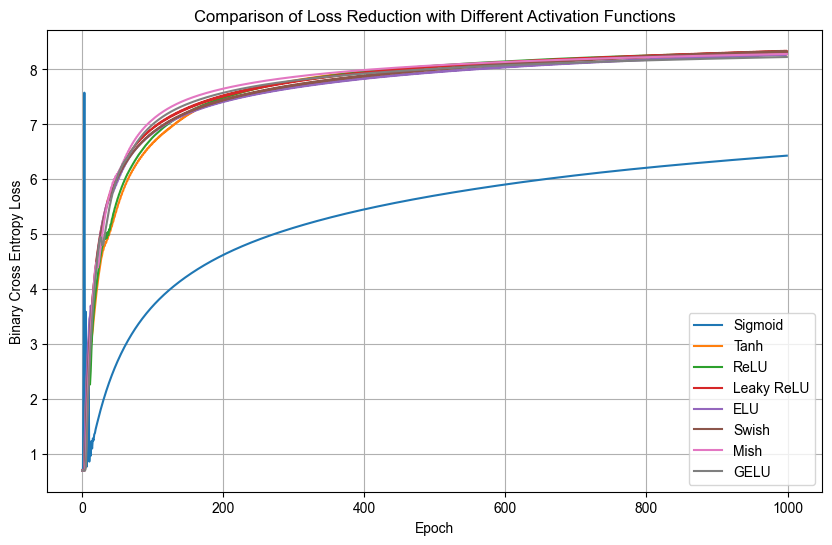

In [56]:

plt.figure(figsize=(10,6))
for name, func in activations_dict.items():
    train_with_activation(func, name)
plt.title("Comparison of Loss Reduction with Different Activation Functions")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 6️⃣ رسم نمودار مقایسه‌ای
```python
plt.plot(losses, label=name)
```


نمودار نشان می‌دهد که کدام تابع فعال‌سازی س

<div dir="rtl" lang="fa" style="direction: rtl; text-align: right; 
     font-family: 'Vazirmatn', 'IRANSans', 'Tahoma', system-ui, sans-serif; 
     line-height: 1.85; 
     font-size: 1.05em; 
     max-width: 920px; 
     margin: 0 auto; 
     padding: 0 3em 0em 0em; 
     box-sizing: border-box;">

<!-- استایل‌های اضافی برای تمایز عنوان‌ها از بدنه -->
<style>
  h1, h2, h3, h4, h5, h6 {
    margin-right: 0.4em;          /* عنوان‌ها کمتر از راست فاصله دارند → راست‌تر */
    padding-right: 0;
    border-right: 3px solid #1976d2;   /* خط رنگی سمت راست عنوان برای زیبایی */
    padding-right: 0.6em;
  }

  p, li, blockquote {
    margin-right: 1.2em;          /* بدنه متن بیشتر از راست فاصله دارد */
    text-indent: 0;
  }

  ul, ol {
    padding-right: 1.5em;         /* لیست‌ها هم کمی داخل‌تر */
    margin-right: 0.8em;
  }

  code, pre {
    direction: ltr;
    text-align: left;
    font-family: 'Fira Code', 'Courier New', monospace;
  }
</style>
## 🔹 نتیجه

میتوان نتیجه گرفت که توابع فعال‌سازی مختلف چگونه روی سرعت و کیفیت یادگیری شبکه اثر می‌گذارند.

 می‌توان داده‌ها و شبکه را تغییر داد تا وضعیت های گوناگون را تجربه کرد.

مفهوم Forward Pass, Backpropagation, و Gradient Update را به شکل ملموس میتوان دید.

Sigmoid        → Loss نهایی: 0.00224
Tanh           → Loss نهایی: 0.00038
ReLU           → Loss نهایی: 0.11982
Leaky ReLU     → Loss نهایی: 0.07401
ELU            → Loss نهایی: 0.29844
Swish          → Loss نهایی: 0.00034
Mish           → Loss نهایی: 0.00525
GELU           → Loss نهایی: 0.00747


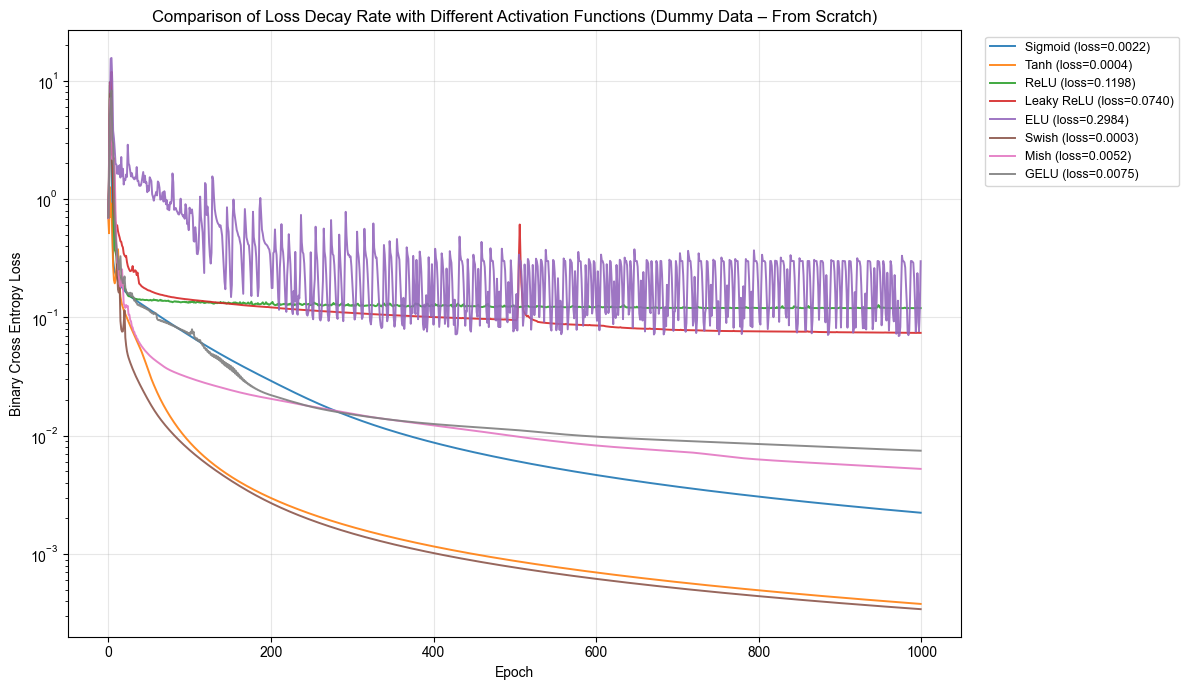

In [57]:
np.random.seed(42)

# داده ساختگی ساده (طبقه‌بندی باینری)
X = np.random.randn(800, 12) * 1.5
true_W = np.random.randn(12, 1) * 0.8
y_prob = sigmoid(X @ true_W + 0.3)
y = (np.random.rand(800, 1) < y_prob).astype(float)

input_size  = 12
hidden_size = 40
output_size = 1
learning_rate = 0.01
epochs = 1000

def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# مشتق توابع فعال‌سازی (برای backpropagation)
def derivative(func, x, name):
    if name == "Sigmoid":
        s = sigmoid(x)
        return s * (1 - s)
    elif name == "Tanh":
        return 1 - np.tanh(x)**2
    elif name == "ReLU":
        return (x > 0).astype(float)
    elif name == "Leaky ReLU":
        return np.where(x > 0, 1.0, 0.01)
    elif name == "ELU":
        alpha = 1.0
        return np.where(x > 0, 1.0, alpha * np.exp(x))
    elif name == "Swish":
        beta = 1.0
        s = sigmoid(beta * x)
        return s + beta * x * s * (1 - s)
    elif name == "Mish":
        sp = np.log(1 + np.exp(x))
        return np.tanh(sp) + x * (1 - np.tanh(sp)**2) * (1 / (1 + np.exp(-x)))
    elif name == "GELU":
        # تقریب مشتق (برای سادگی)
        cdf = 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
        pdf_approx = 0.5 * np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)  # gaussian pdf
        return cdf + x * pdf_approx
    return np.ones_like(x)

# آموزش و مقایسه
activations_list = [
    ("Sigmoid",        sigmoid,        "Sigmoid"),
    ("Tanh",           tanh,           "Tanh"),
    ("ReLU",           relu,           "ReLU"),
    ("Leaky ReLU",     lambda z: leaky_relu(z, 0.01), "Leaky ReLU"),
    ("ELU",            lambda z: elu(z, 1.0),        "ELU"),
    ("Swish",          lambda z: swish(z, 1.0),      "Swish"),
    ("Mish",           mish,           "Mish"),
    ("GELU",           gelu,           "GELU"),
]

plt.figure(figsize=(12, 7))

for name_display, activation_func, deriv_name in activations_list:
    # مقداردهی اولیه وزن‌ها
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)   # He init برای ReLU-like
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    losses = []

    for epoch in range(epochs):
        # Forward
        z1 = X @ W1 + b1
        a1 = activation_func(z1)
        z2 = a1 @ W2 + b2
        a2 = sigmoid(z2)   # خروجی نهایی sigmoid

        loss = binary_cross_entropy(y, a2)
        losses.append(loss)

        # Backward
        dz2 = a2 - y
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ W2.T
        dz1 = da1 * derivative(activation_func, z1, deriv_name)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # به‌روزرسانی
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    final_loss = losses[-1]
    print(f"{name_display:14} → Loss نهایی: {final_loss:.5f}")

    # رسم منحنی loss
    plt.plot(losses, label=f"{name_display} (loss={final_loss:.4f})", linewidth=1.4, alpha=0.9)

plt.title("Comparison of Loss Decay Rate with Different Activation Functions (Dummy Data – From Scratch)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### مقایسه تحلیلی (بر اساس مقالات مروری):
| Activation   | 1. Output Range                       | 2. Monotonicity           | 3. Smoothness                   | 4. Gradient Flow           | 5. Convergence Speed    | 6. Final Accuracy       | 7. Computational Cost   | 8. Training Stability   | 9. Scalability (Deep Nets)   |
|:-------------|:--------------------------------------|:--------------------------|:--------------------------------|:---------------------------|:------------------------|:------------------------|:------------------------|:------------------------|:-----------------------------|
| Sigmoid      | [0,1] (محدود → مناسب احتمال)          | صعودی (پایدار)            | پیوسته مشتق‌پذیر (بهینه‌سازی خوب) | محو در |x| بزرگ (بد)       | کند (vanishing)         | متوسط (تصویر/متن)       | بالا (exp)              | متوسط (حساس به init)    | ضعیف (>50 لایه)              |
| Tanh         | [-1,1] (محدود → مناسب رگرسیون متعادل) | صعودی (پایدار)            | پیوسته (خوب)          

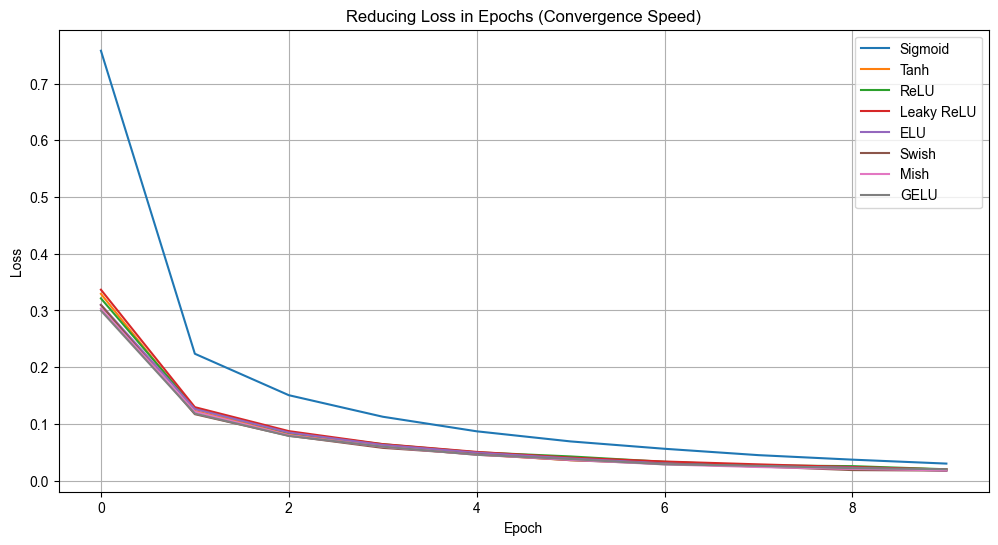

In [58]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt


# تعریف توابع فعال‌سازی (from scratch برای numpy, اما برای مدل از torch استفاده می‌شود)
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)
def leaky_relu(x, alpha=0.01): return np.where(x > 0, x, alpha * x)
def elu(x, alpha=1.0): return np.where(x > 0, x, alpha * (np.exp(x) - 1))
def swish(x): return x * sigmoid(x)
def mish(x): return x * np.tanh(np.log(1 + np.exp(x)))
def gelu_approx(x): return x * 0.5 * (1.0 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

# لیست توابع برای جدول تحلیلی
activations = [
    'Sigmoid', 'Tanh', 'ReLU', 'Leaky ReLU', 'ELU', 'Swish', 'Mish', 'GELU'
]

# داده‌های تحلیلی بر اساس مقالات (arXiv:2109.14545, arXiv:2405.04459 و غیره)
comparison_data = {
    'Activation': activations,
    '1. Output Range': [
        '[0,1] (محدود → مناسب احتمال)', '[-1,1] (محدود → مناسب رگرسیون متعادل)',
        '[0, ∞) (نامحدود → مناسب رگرسیون)', '(-∞, ∞) (نامحدود → رگرسیون عمومی)',
        '(-1, ∞) (نامحدود → رگرسیون)', '≈(-0.3, ∞) (نامحدود → رگرسیون)',
        '≈(-0.3, ∞) (نامحدود → رگرسیون)', '≈(-0.17, ∞) (نامحدود → رگرسیون)'
    ],
    '2. Monotonicity': [
        'صعودی (پایدار)', 'صعودی (پایدار)', 'صعودی (پایدار)',
        'صعودی (پایدار)', 'صعودی (پایدار)', 'غیرصعودی (الگوهای پیچیده)',
        'غیرصعودی (الگوهای پیچیده)', 'غیرصعودی (الگوهای پیچیده)'
    ],
    '3. Smoothness': [
        'پیوسته مشتق‌پذیر (بهینه‌سازی خوب)', 'پیوسته (خوب)', 'ناصاف در 0 (ممکن مشکل)',
        'ناصاف در 0 (بهتر از ReLU)', 'پیوسته (خوب)', 'پیوسته (عالی)',
        'پیوسته (عالی)', 'پیوسته (عالی)'
    ],
    '4. Gradient Flow': [
        'محو در |x| بزرگ (بد)', 'محو در |x| بزرگ (بد)', 'صفر برای منفی (Dying ReLU)',
        'شیب کوچک برای منفی (بهتر)', 'بهتر برای منفی (کم محو)', 'خوب (کم محو)',
        'عالی (کم محو)', 'عالی (کم محو)'
    ],
    '5. Convergence Speed': [
        'کند (vanishing)', 'کند (vanishing)', 'سریع (استاندارد)',
        'سریع‌تر از ReLU', 'سریع (در بنچمارک‌ها)', 'سریع‌تر در عمیق',
        'سریع‌تر از Swish در برخی', 'سریع در Transformer'
    ],
    '6. Final Accuracy': [
        'متوسط (تصویر/متن)', 'متوسط (متن)', 'خوب (تصویر)', 'بهتر از ReLU (تصویر)',
        'خوب در NLP', 'عالی در CV/NLP', 'عالی در CV', 'عالی در NLP/Transformer'
    ],
    '7. Computational Cost': [
        'بالا (exp)', 'بالا (exp)', 'کم (max)', 'کم (where)', 'متوسط (exp)',
        'متوسط (sigmoid)', 'بالا (log/exp)', 'متوسط (erf)'
    ],
    '8. Training Stability': [
        'متوسط (حساس به init)', 'متوسط (حساس)', 'خوب اما dying', 'بهتر (کم dying)',
        'عالی با init خوب', 'خوب', 'عالی (کم نویز)', 'عالی (کم نویز)'
    ],
    '9. Scalability (Deep Nets)': [
        'ضعیف (>50 لایه)', 'ضعیف', 'خوب تا 100', 'بهتر', 'خوب در عمیق',
        'عالی (>100)', 'عالی (>100)', 'عالی در Transformer'
    ]
}

# ساخت جدول Markdown
df = pd.DataFrame(comparison_data)
print("### مقایسه تحلیلی (بر اساس مقالات مروری):")
print(df.to_markdown(index=False))

# بخش تجربی: مدل MLP روی MNIST با PyTorch
class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.activation = activation
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

# بارگذاری MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# تابع آموزش و ارزیابی
def train_and_evaluate(activation_name, activation):
    model = MLP(activation)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    start_time = time.time()
    epochs = 10
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            # Gradient clipping برای پایداری
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))

    training_time = time.time() - start_time

    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    accuracy = 100. * correct / len(test_dataset)
    stability = np.std(losses)  # variance loss برای پایداری

    print(f'\n{activation_name}: دقت: {accuracy:.2f}%, زمان: {training_time:.2f}s, loss نهایی: {losses[-1]:.4f}, پایداری (std loss): {stability:.4f}, سرعت همگرایی (loss پس از 5 epoch): {losses[4]:.4f}')

    plt.plot(losses, label=activation_name)

    return {
        'دقت نهایی': accuracy,
        'زمان محاسباتی': training_time,
        'loss نهایی': losses[-1],
        'پایداری': stability,
        'سرعت همگرایی (epoch 5)': losses[4] if len(losses) > 4 else losses[-1]
    }

# لیست اکتیویشن‌های torch
torch_activations = {
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'Leaky ReLU': nn.LeakyReLU(0.01),
    'ELU': nn.ELU(1.0),
    'Swish': nn.SiLU(),  # Swish در PyTorch
    'Mish': nn.Mish(),
    'GELU': nn.GELU()
}

# اجرا و مقایسه تجربی
print("\n### مقایسه تجربی روی MNIST (MLP ساده, 10 epoch):")
results = {}
plt.figure(figsize=(12, 6))
for name, act in torch_activations.items():
    results[name] = train_and_evaluate(name, act)

# جدول نتایج تجربی
exper_df = pd.DataFrame(results).T
print(exper_df.to_markdown())

plt.title('Reducing Loss in Epochs (Convergence Speed)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()